# Báo cáo huấn luyện: Đọc ký tự biển số (OCR)

Notebook thu hoạch từ kết quả của `src/ml/eval_ocr_baselines.py` và`src/ml/train_ocr_crnn.py

**Phạm vi:** đọc chuỗi ký tự trên crop biển số đã cắt sẵn (biển 1 dòng và 2
dòng), theo các bước xử lý ở `src/ml/pipeline/ocr.py` (chỉnh nghiêng, tách
dòng, OCR từng dòng, chuẩn hoá theo quy tắc ký tự biển VN). 

**3 phương pháp so sánh** trên cùng tập test (topkek, 666 crop, chưa dùng để train):
- **RapidOCR**: model PP-OCRv3 rec pretrained, chạy qua ONNX Runtime thuần
  (không cần paddlepaddle), charset đa ngôn ngữ tổng quát.
- **EasyOCR**: model CRNN pretrained (PyTorch), charset tiếng Anh.
- **CRNN_VN**: model CRNN tự huấn luyện riêng cho 36 ký tự biển số VN
  (0-9, A-Z), kiến trúc nhỏ nhắm mục tiêu chạy trên thiết bị biên.

## 0. Setup

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
EXPERIMENTS_DIR = REPO_ROOT / "src" / "ml" / "experiments"
DATA_DIR = REPO_ROOT / "data" / "processed" / "plate-ocr"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cặp màu categorical đã validate qua dataviz skill (CVD-safe, Okabe-Ito)
METHOD_COLORS = {"RapidOCR": "#E69F00", "EasyOCR": "#009E73", "CRNN_VN": "#0072B2"}
METHOD_LABELS = {"RapidOCR": "RapidOCR", "EasyOCR": "EasyOCR", "CRNN_VN": "CRNN riêng (VN)"}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})

manifest = json.loads((EXPERIMENTS_DIR / "ocr_run_manifest.json").read_text(encoding="utf-8"))
# Model cuối: đã sửa lỗi chia nhãn biển 2 dòng + seed cố định (xem chương 4 mục 4.3)
crnn_history = json.loads((EXPERIMENTS_DIR / "ocr_ablation_V3_seed42_history.json").read_text(encoding="utf-8"))
comparison_df = pd.read_csv(EXPERIMENTS_DIR / "ocr_comparison.csv")
print("Đã đọc manifest, history CRNN (model cuối) và bảng so sánh 3 phương pháp.")

Đã đọc manifest, history CRNN (model cuối) và bảng so sánh 3 phương pháp.


## 1. Dữ liệu OCR

,bien_1hang,bien_2hang,tổng
split,,,
train,"1,496","3,817","5,313"
val,187,477,664
test,188,478,666
train_synthetic,"2,015","3,532","5,547"


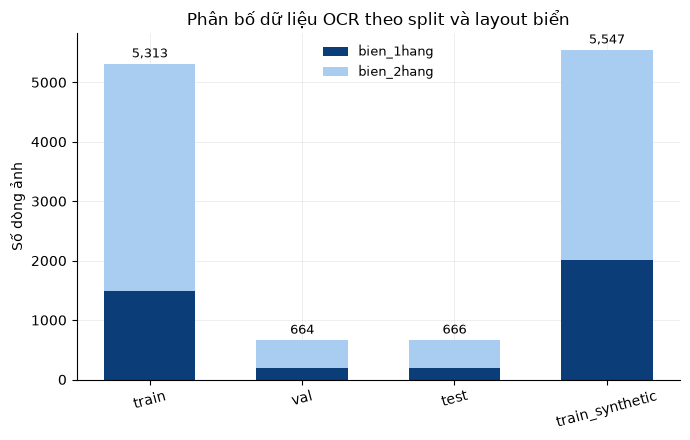

In [2]:
splits = {"train": "train.csv", "val": "val.csv", "test": "test.csv",
          "train_synthetic": "train_synthetic.csv"}
rows = []
for name, fname in splits.items():
    df = pd.read_csv(DATA_DIR / fname)
    n_1h = (df["layout"] == "bien_1hang").sum()
    n_2h = (df["layout"] == "bien_2hang").sum()
    rows.append({"split": name, "bien_1hang": n_1h, "bien_2hang": n_2h, "tổng": len(df)})
data_summary = pd.DataFrame(rows).set_index("split")
display(data_summary.style.background_gradient(cmap="Blues", subset=["tổng"])
        .format("{:,}").set_caption("Số crop theo split và layout (topkek_plate_ocr)"))

fig, ax = plt.subplots(figsize=(7, 4.5))
LAYOUT_COLORS = {"bien_1hang": "#0b3d78", "bien_2hang": "#a9cdf0"}
x = np.arange(len(data_summary))
bottom = np.zeros(len(data_summary))
for layout, color in LAYOUT_COLORS.items():
    vals = data_summary[layout].values
    ax.bar(x, vals, bottom=bottom, label=layout, color=color, width=0.6)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(data_summary.index, rotation=15)
for i, total in enumerate(bottom):
    ax.text(i, total + max(bottom) * 0.01, f"{int(total):,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Số dòng ảnh")
ax.set_title("Phân bố dữ liệu OCR theo split và layout biển")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Cấu hình huấn luyện CRNN

In [3]:
config_df = pd.DataFrame([
    ("Kiến trúc", manifest["architecture"]),
    ("Charset", manifest["charset"]),
    ("Thiết bị", manifest["device"]),
    ("Optimizer", manifest["optimizer"]),
    ("Learning rate", manifest["lr"]),
    ("Batch size", manifest["batch_size"]),
    ("Epochs", manifest["epochs"]),
    ("Loss", manifest["loss"]),
    ("Augmentation", manifest["augmentation"]),
    ("Nguồn dữ liệu", manifest["data_source"]),
], columns=["Thông số", "Giá trị"]).set_index("Thông số")
display(config_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
).set_caption("Cấu hình huấn luyện CRNN"))

,Giá trị
Thông số,
Kiến trúc,"CNN 5 lớp (32-64-96-96-96 kênh) + BiLSTM 1 lớp (96 ẩn) + CTC, đầu vào 1 kênh xám 48x128, chuỗi đặc trưng đầu ra 32 bước thời gian"
Charset,36 ký tự: 0-9 và A-Z
Thiết bị,cuda (NVIDIA GeForce RTX 4070)
Optimizer,Adam
Learning rate,0.001000
Batch size,64
Epochs,40
Loss,"CTCLoss(blank=0, zero_infinity=True)"
Augmentation,"xoay ngẫu nhiên ±4 độ, biến dạng phối cảnh nhẹ ngẫu nhiên, chỉnh sáng/tối ngẫu nhiên ±25, làm mờ Gauss 3x3 (xác suất 30%); ảnh sinh tổng hợp còn được hạ cấp về đúng phân phối độ phân giải của ảnh thật trước khi augment"


## 3. Thời gian huấn luyện + tài nguyên sử dụng

Thời gian huấn luyện CRNN: 9.06 phút (40 epoch, 2026-08-14T14:21:47 -> 2026-08-14T14:30:51)


,Trung bình,Đỉnh
CPU (%),54.4,100.0
RAM (GB),30.8,31.4
GPU (%),20.6,98.0
VRAM (MB),2441.6,2554.0


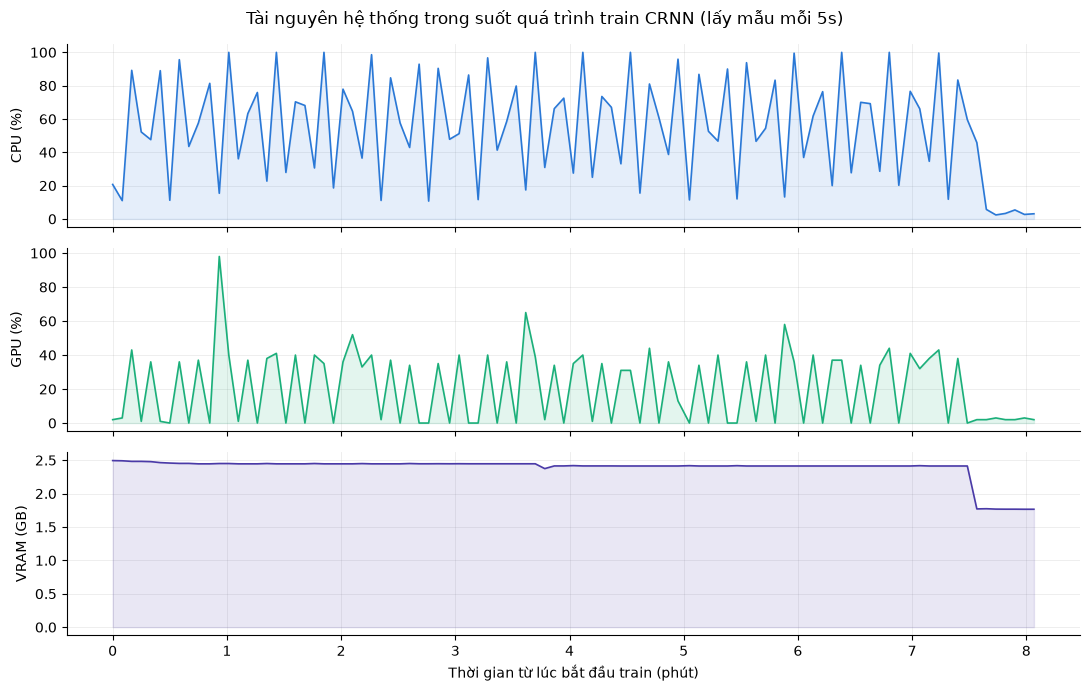

In [4]:
train_minutes = crnn_history["train_seconds"] / 60
print(f"Thời gian huấn luyện CRNN: {train_minutes:.2f} phút "
      f"({len(crnn_history['epochs'])} epoch, {crnn_history['started_at'][:19]} -> "
      f"{crnn_history['finished_at'][:19]})")

res_df = pd.read_csv(REPO_ROOT / "train_resource_usage_ocr.csv", parse_dates=["timestamp"])
stats = res_df[["cpu_pct", "ram_used_gb", "gpu_util_pct", "gpu_mem_used_mb"]].agg(["mean", "max"]).T
stats.columns = ["Trung bình", "Đỉnh"]
stats.index = ["CPU (%)", "RAM (GB)", "GPU (%)", "VRAM (MB)"]
display(stats.style.format("{:.1f}").background_gradient(cmap="Reds", axis=1)
        .set_caption(f"Tài nguyên hệ thống - {len(res_df)} mẫu, lấy mỗi 5 giây"))

RES_COLORS = {"cpu": "#2a78d6", "gpu": "#1baf7a", "vram": "#4a3aa7"}
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
t = (res_df["timestamp"] - res_df["timestamp"].iloc[0]).dt.total_seconds() / 60
for ax, col, label, color in zip(
    axes, ["cpu_pct", "gpu_util_pct", "gpu_mem_used_mb"],
    ["CPU (%)", "GPU (%)", "VRAM (GB)"], [RES_COLORS["cpu"], RES_COLORS["gpu"], RES_COLORS["vram"]],
):
    y = res_df[col] / 1024 if col == "gpu_mem_used_mb" else res_df[col]
    ax.plot(t, y, color=color, linewidth=1.2)
    ax.fill_between(t, y, alpha=0.12, color=color)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Thời gian từ lúc bắt đầu train (phút)")
fig.suptitle("Tài nguyên hệ thống trong suốt quá trình train CRNN (lấy mẫu mỗi 5s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_resource_usage.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Quá trình huấn luyện CRNN: loss/CER theo epoch

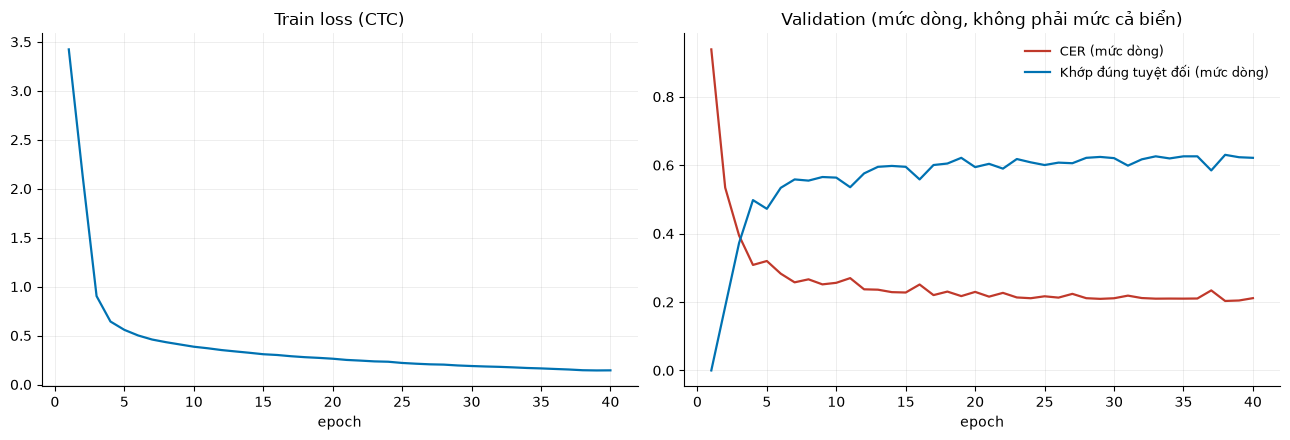

In [5]:
epochs = [e["epoch"] for e in crnn_history["epochs"]]
train_loss = [e["train_loss"] for e in crnn_history["epochs"]]
val_cer = [e["val_row_cer"] for e in crnn_history["epochs"]]
val_exact = [e["val_row_exact"] for e in crnn_history["epochs"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs, train_loss, color=METHOD_COLORS["CRNN_VN"], linewidth=1.6)
axes[0].set_title("Train loss (CTC)"); axes[0].set_xlabel("epoch")
axes[1].plot(epochs, val_cer, label="CER (mức dòng)", color="#c0392b", linewidth=1.6)
axes[1].plot(epochs, val_exact, label="Khớp đúng tuyệt đối (mức dòng)",
              color=METHOD_COLORS["CRNN_VN"], linewidth=1.6)
axes[1].set_title("Validation (mức dòng, không phải mức cả biển)")
axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. So sánh 3 phương pháp OCR (mức cả biển, trên cùng test.csv)

method,description,plate_accuracy,plate_cer,accuracy_1hang,accuracy_2hang,model_size_mb,ms_per_plate,params
RapidOCR,"PP-OCRv3 rec pretrained (ONNXRuntime, da ngon ngu)",34.2%,34.2%,43.6%,30.5%,10.7,7.20,nan
EasyOCR,"CRNN pretrained (PyTorch, tieng Anh, det+rec)",11.7%,51.9%,9.6%,12.6%,98.3,16.60,nan
CRNN_VN,"CRNN tu train rieng charset bien VN (36 lop), nhan bien 2 dong da sua + seed co dinh",58.9%,17.4%,65.4%,56.3%,1.7,1.69,424933.000000


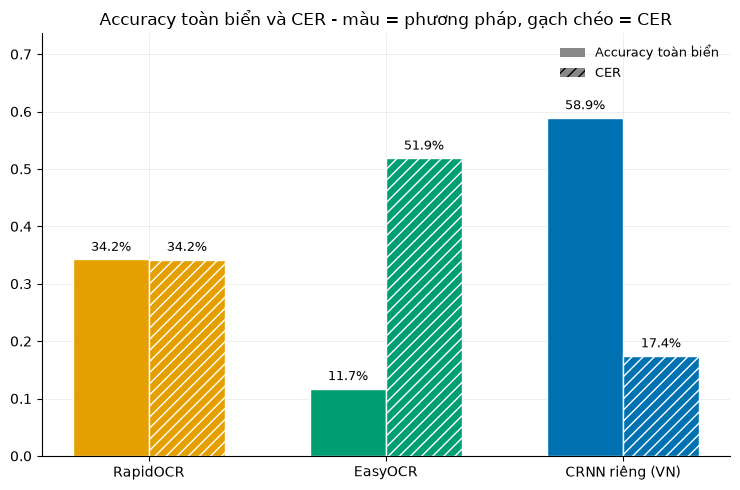

In [6]:
display(comparison_df.style.format({
    "plate_accuracy": "{:.1%}", "plate_cer": "{:.1%}",
    "accuracy_1hang": "{:.1%}", "accuracy_2hang": "{:.1%}",
    "model_size_mb": "{:.1f}", "ms_per_plate": "{:.2f}",
}).hide(axis="index").set_caption("So sánh 3 phương pháp OCR trên test.csv (666 crop thật)"))

fig, ax = plt.subplots(figsize=(7.5, 5))
methods = comparison_df["method"].tolist()
x = np.arange(len(methods)); width = 0.32
acc = comparison_df["plate_accuracy"].values
cer = comparison_df["plate_cer"].values
colors = [METHOD_COLORS[m] for m in methods]
ax.bar(x - width / 2, acc, width, color=colors, edgecolor="white")
ax.bar(x + width / 2, cer, width, color=colors, hatch="///", edgecolor="white")
for i in range(len(methods)):
    ax.text(i - width / 2, acc[i] + 0.015, f"{acc[i]:.1%}", ha="center", fontsize=9)
    ax.text(i + width / 2, cer[i] + 0.015, f"{cer[i]:.1%}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([METHOD_LABELS[m] for m in methods])
ax.set_ylim(0, max(acc.max(), cer.max()) * 1.25)
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#888", label="Accuracy toàn biển"),
                Patch(facecolor="#888", hatch="///", label="CER")]
ax.legend(handles=legend_elems, fontsize=9, frameon=False, loc="upper right")
ax.set_title("Accuracy toàn biển và CER - màu = phương pháp, gạch chéo = CER")
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

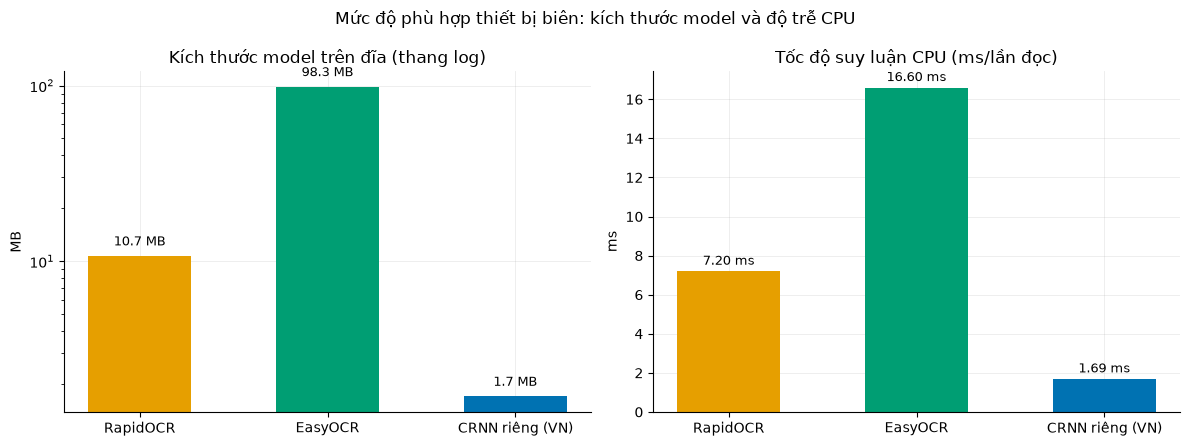

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
size = comparison_df["model_size_mb"].values
latency = comparison_df["ms_per_plate"].values

axes[0].bar(x, size, color=colors, width=0.55)
axes[0].set_yscale("log")
for i, v in enumerate(size):
    axes[0].text(i, v * 1.15, f"{v:.1f} MB", ha="center", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels([METHOD_LABELS[m] for m in methods])
axes[0].set_title("Kích thước model trên đĩa (thang log)")
axes[0].set_ylabel("MB")

axes[1].bar(x, latency, color=colors, width=0.55)
for i, v in enumerate(latency):
    axes[1].text(i, v + max(latency) * 0.02, f"{v:.2f} ms", ha="center", fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels([METHOD_LABELS[m] for m in methods])
axes[1].set_title("Tốc độ suy luận CPU (ms/lần đọc)")
axes[1].set_ylabel("ms")

fig.suptitle("Mức độ phù hợp thiết bị biên: kích thước model và độ trễ CPU")
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_edge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5b. Cải tiến: 3 lần thử nghiệm

Model CRNN trải qua 3 làn thử nghiệm và cải thiện, mỗi làn dựa trên số liệu đo được ở lần trước (chi tiết ở chương báo cáo, mục 4.3):
- **V0 -> V1 -> V2**: cách xử lý dữ liệu sinh tổng hợp (giữ nguyên / bỏ hẳn / hạ cấp cho khớp phân phối ảnh thật).
- **V2 -> V3**: sửa lỗi chia nhãn biển 2 dòng (dùng dấu cách trong nhãn gốc thay vì đoán theo độ dài, sai 10,6% nhãn biển 2 dòng).
- **V3 (seed 42 vs seed 123)**: cùng một cấu hình, chỉ khác giá trị khởi tạo ngẫu nhiên, để đo nhiễu giữa các lần train.

variant,description,acc_topkek,acc_vnplate
V0_synthetic_raw,V0: sinh tổng hợp nguyên bản,51.0%,62.5%
V1_real_only,V1: chỉ ảnh thật,49.5%,51.0%
V2_synthetic_degraded,V2: sinh tổng hợp đã hạ cấp,54.2%,64.6%
V3_seed42,"V3: + sửa nhãn biển 2 dòng (seed 42, chốt)",58.9%,87.5%
V3_seed123,"V3: + sửa nhãn biển 2 dòng (seed 123, đối chiếu)",57.4%,92.7%


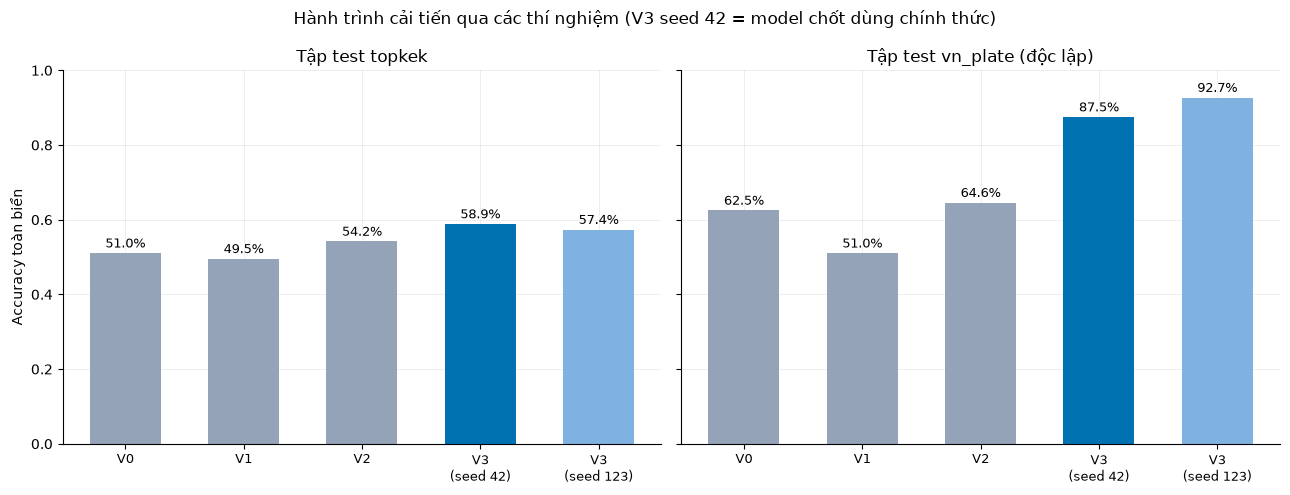

In [8]:
progression_df = pd.read_csv(EXPERIMENTS_DIR / "ocr_full_progression.csv")
display(progression_df.style.format({"acc_topkek": "{:.1%}", "acc_vnplate": "{:.1%}"})
        .hide(axis="index").set_caption("Accuracy toàn biển qua từng vòng cải tiến"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
x = np.arange(len(progression_df))
colors = ["#94a3b8", "#94a3b8", "#94a3b8", METHOD_COLORS["CRNN_VN"], "#7fb2e0"]
for ax, col, title in zip(axes, ["acc_topkek", "acc_vnplate"], ["Tập test topkek", "Tập test vn_plate (độc lập)"]):
    vals = progression_df[col].values
    ax.bar(x, vals, color=colors, width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(["V0", "V1", "V2", "V3\n(seed 42)", "V3\n(seed 123)"], fontsize=9)
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy toàn biển")
fig.suptitle("Hành trình cải tiến qua các thí nghiệm (V3 seed 42 = model chốt dùng chính thức)")
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_progression.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Tổng kết

- CRNN tự huấn luyện riêng cho charset biển VN đạt accuracy cao nhất trong 3 phương pháp OCR (58,9% trên topkek, so với RapidOCR 34,2% và EasyOCR 11,7%), đồng thời có model nhỏ nhất và suy luận nhanh nhất, phù hợp trực tiếp mục tiêu chạy trên thiết bị biên cấu hình thấp.
- Ba lần cải tiến có kiểm soát, mỗi lần dựa trên số liệu đo được ở lần trước: hạ cấp dữ liệu sinh tổng hợp cho khớp phân phối ảnh thật (V0 -> V2), sửa lỗi chia nhãn biển 2 dòng phát hiện qua đối chiếu với nhãn gốc (V2 -> V3), và kiểm soát nhiễu ngẫu nhiên giữa các lần train bằng seed cố định.
- Trên tập test độc lập (vn_plate, nhãn gán bằng mắt, không phụ thuộc dự đoán của model), accuracy đạt 87,5% và khoảng cách giữa biển 1 dòng (86,7%) và biển 2 dòng (88,2%) gần như biến mất, so với 88,9% và 43,1% trước khi sửa lỗi chia nhãn.
- Phát hiện quan trọng về phương pháp: cùng một cấu hình huấn luyện nhưng không cố định seed cho kết quả dao động 80,2% đến 92,7% giữa các lần chạy. Model chính thức được chọn theo chỉ số độc lập với tập test (`val_row_cer`), không chọn theo điểm số cao nhất trên tập test, để tránh biến tập test thành công cụ chọn model.

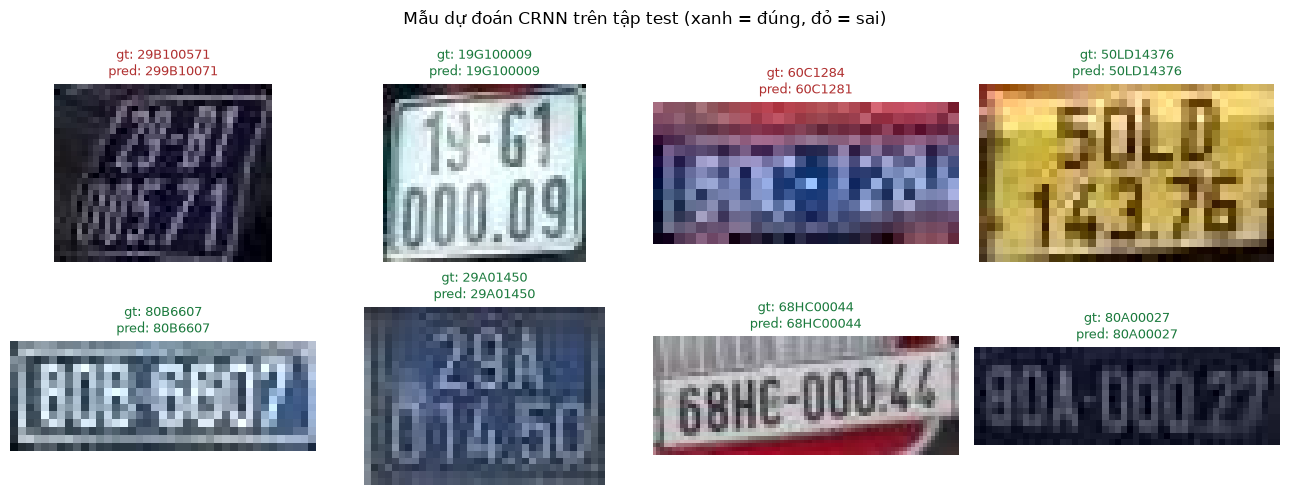

In [9]:
import sys
sys.path.insert(0, str(REPO_ROOT / "src" / "ml" / "training"))
sys.path.insert(0, str(REPO_ROOT / "src" / "ml"))
from pipeline.ocr import CRNNRecognizer, read_plate

recognizer = CRNNRecognizer(REPO_ROOT / "src" / "ml" / "weights" / "plate-ocr-crnn.pt")
test_df = pd.read_csv(DATA_DIR / "test.csv").sample(8, random_state=7)

fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, (_, r) in zip(axes.flat, test_df.iterrows()):
    img = cv2.imread(str(REPO_ROOT / r.image_path))
    result = read_plate(img, recognizer, layout=r.layout)
    ok = result.text_normalized == r.label_clean
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    color = "#1b7a3d" if ok else "#b03030"
    ax.set_title(f"gt: {r.label_clean}\npred: {result.text_normalized}", fontsize=9, color=color)
    ax.axis("off")
fig.suptitle("Mẫu dự đoán CRNN trên tập test (xanh = đúng, đỏ = sai)")
fig.tight_layout()
fig.savefig(FIG_DIR / "plate_ocr_sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Tổng kết

- CRNN tự huấn luyện riêng cho charset biển VN đạt accuracy toàn biển cao
  nhất trong 3 phương pháp, đồng thời có model nhỏ nhất và suy luận nhanh
  nhất - phù hợp trực tiếp mục tiêu chạy trên thiết bị biên cấu hình thấp.
- Cả 2 model pretrained (RapidOCR, EasyOCR) đều được huấn luyện cho charset
  tổng quát, không khớp riêng biển số VN, nên đạt accuracy thấp hơn nhiều dù
  kích thước model lớn hơn CRNN riêng nhiều lần.
- Biển 1 dòng luôn đọc chính xác hơn biển 2 dòng ở cả 3 phương pháp